In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Gram-Smidth orthonormalization

Given a set of vectors $S = \{\mathbf{a}_1, \mathbf{a}_2, \dots, \mathbf{a}_m\}$ where $\mathbf{a}_i \in \mathbb{R}^n, i=1, 2, \dots, m$, we can convert $S$ into an orthonormal set of vectors $E$ that span the same space. 

1. Set $\mathbf{q}_1 = \dfrac{\mathbf{a}_1}{||\mathbf{a}_1||}$, (normalize the first vector)
2. For $i = 2, 3, \dots, k$:
   - Set $\mathbf{z}_i = \mathbf{a}_i - \text{proj}_{\text{Span}(\mathbf{q}_1, \dots, \mathbf{q}_{i-1})}(\mathbf{a}_i)$
   - Set $\mathbf{q}_i = \dfrac{\mathbf{z}_i}{||\mathbf{z}_i||}$

Where $\text{proj}_{\text{Span}(\mathbf{q}_1, \dots, \mathbf{q}_{i-1})}(\mathbf{a}_i)$ is defined as
$$
    \text{proj}_{\text{Span}(\mathbf{q}_1, \dots, \mathbf{q}_{i-1})}(\mathbf{a}_i) = \sum_{k=1}^{i-1} \left<\mathbf{a}_i, \mathbf{q}_k\right> \mathbf{q}_k
$$


In [58]:
def proj(a, span):
    return np.sum([(a @ q)/(q @ q) * q for q in span], axis=0)

S = [
    np.array([2, 1, 0]),
    np.array([1, 0, 3]),
    np.array([0, 8, 0])
]

E = [S[0]/np.linalg.norm(S[0])]

for i in range(1, len(S)):
    zi = S[i] - proj(S[i], E)
    E.append(zi/np.linalg.norm(zi))

E, [np.linalg.norm(q) for q in E]

([array([0.89442719, 0.4472136 , 0.        ]),
  array([ 0.06593805, -0.13187609,  0.98907071]),
  array([-0.44232587,  0.88465174,  0.14744196])],
 [0.9999999999999999, 1.0, 1.0])

In [61]:
[[round(qi @ qj) for qi in E] for qj in E]

[[1, 0, 0], [0, 1, 0], [0, 0, 1]]

## Example visualization

In [101]:
def draw_vector2d(vec, label, color, ax=None):
    ax = ax if ax is not None else plt

    props = dict(arrowstyle= '-|>',
                color=color,
                lw=3.5)

    ax.plot([0, vec[0]], [0, vec[1]], label=label, color=color)
    ax.annotate("", xytext=(0, 0), xy=vec, arrowprops=props)
    ax.annotate(label, xytext=vec, xy=vec)
    

### 1. Plot two vectors

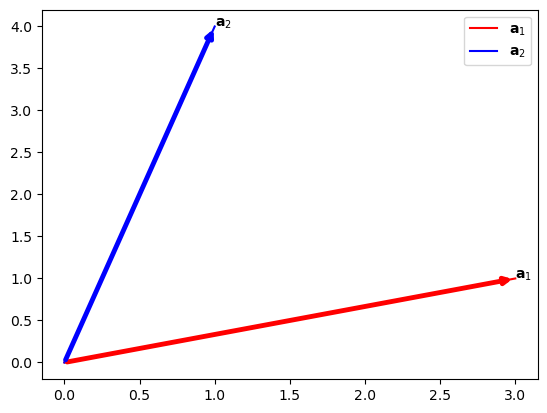

In [102]:
a1 = np.array([3, 1])
a2 = np.array([1, 4])

draw_vector2d(a1, r"$\mathbf{a}_1$", "red")
draw_vector2d(a2, r"$\mathbf{a}_2$", "blue")
plt.legend()

### 2. Normalize a1

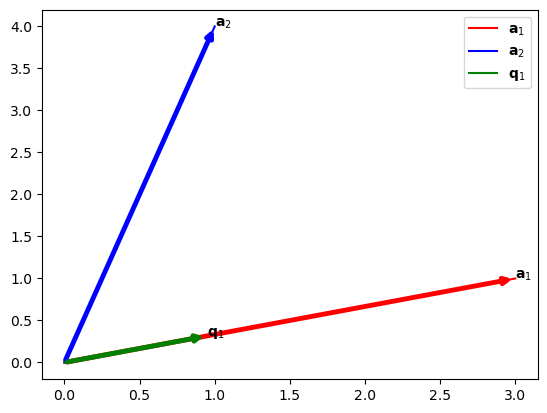

In [108]:
q1 = a1/np.linalg.norm(a1)

draw_vector2d(a1, r"$\mathbf{a}_1$", "red")
draw_vector2d(a2, r"$\mathbf{a}_2$", "blue")
draw_vector2d(q1, r"$\mathbf{q}_1$", "green")

plt.legend()

### 3. Project a2 onto q1

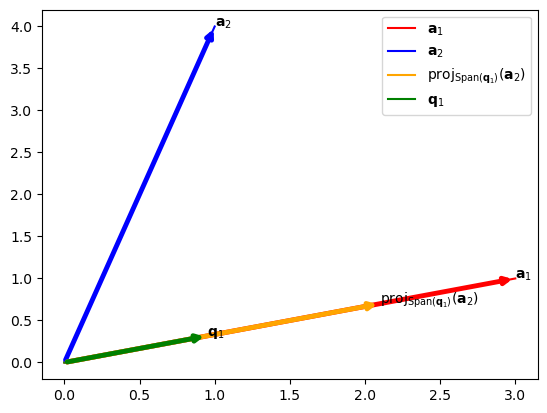

In [104]:
proj_q1_a2 = proj(a2, [q1])

draw_vector2d(a1, r"$\mathbf{a}_1$", "red")
draw_vector2d(a2, r"$\mathbf{a}_2$", "blue")
draw_vector2d(proj_q1_a2, r"$\text{proj}_{\text{Span}(\mathbf{q}_1)}(\mathbf{a}_2)$", "orange")
draw_vector2d(q1, r"$\mathbf{q}_1$", "green")

plt.legend()

### 4. Subtract projection from a2

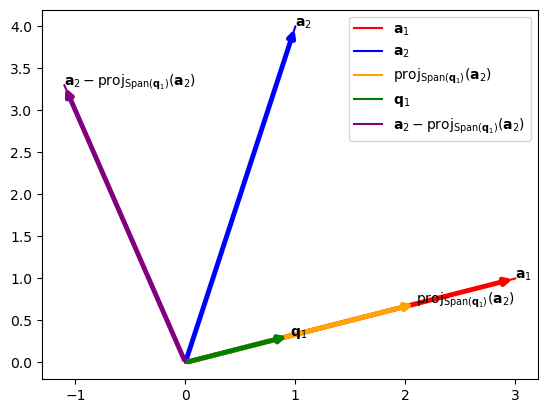

In [105]:

a2_minus_proj_q1_a2 = a2 - proj_q1_a2

draw_vector2d(a1, r"$\mathbf{a}_1$", "red")
draw_vector2d(a2, r"$\mathbf{a}_2$", "blue")
draw_vector2d(proj_q1_a2, r"$\text{proj}_{\text{Span}(\mathbf{q}_1)}(\mathbf{a}_2)$", "orange")
draw_vector2d(q1, r"$\mathbf{q}_1$", "green")
draw_vector2d(a2_minus_proj_q1_a2, r"$\mathbf{a}_2 - \text{proj}_{\text{Span}(\mathbf{q}_1)}(\mathbf{a}_2)$", "purple")

plt.legend()

### 5. Normalize result  

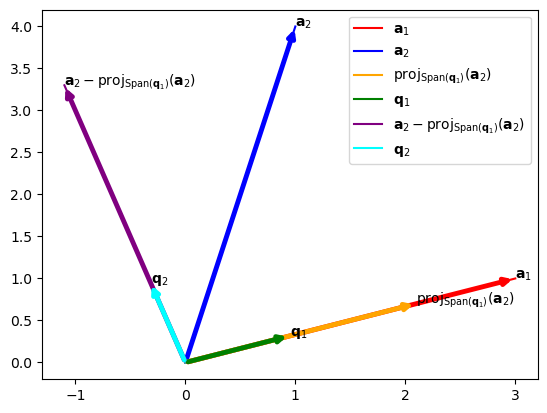

In [106]:

q2 = a2_minus_proj_q1_a2 / np.linalg.norm(a2_minus_proj_q1_a2)

draw_vector2d(a1, r"$\mathbf{a}_1$", "red")
draw_vector2d(a2, r"$\mathbf{a}_2$", "blue")
draw_vector2d(proj_q1_a2, r"$\text{proj}_{\text{Span}(\mathbf{q}_1)}(\mathbf{a}_2)$", "orange")
draw_vector2d(q1, r"$\mathbf{q}_1$", "green")
draw_vector2d(a2_minus_proj_q1_a2, r"$\mathbf{a}_2 - \text{proj}_{\text{Span}(\mathbf{q}_1)}(\mathbf{a}_2)$", "purple")
draw_vector2d(q2, r"$\mathbf{q}_2$", "cyan")

plt.legend()

In [109]:
q1 @ q2

-1.6653345369377348e-16

## QR decomposition

Suppose $\{\mathbf{a}_1, \mathbf{a}_2, \dots, \mathbf{a}_\ell\}$ are the columns of $A$. After applying Gram-Schmidt, we obtain a same-sized set of orthonormal vectors $\{\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_\ell\}$. Because we assume $A$ is full-rank, its columns must be linearly independent, and therefore, the two sets have equal elements. 

We can create a matrix $Q$ out of the orthonormal vectors $\{\mathbf{q}_1, \mathbf{q}_2, \dots, \mathbf{q}_\ell\}$
$$
	Q = \begin{bmatrix}\mathbf{q}_1 & \mathbf{q}_2 & \dots & \mathbf{q}_\ell \end{bmatrix} \in \mathbb{R}^{n \times \ell}
$$
The matrix $R$ is constructed by considering $\mathbf{r}_{(i)} = Q_{(i)}^T \mathbf{a}_i$. This means that we are taking inner products in a triangular structure
$$
	R = \begin{bmatrix} 
		\left<\mathbf{a}_1, \mathbf{q}_1 \right> & \left<\mathbf{a}_2, \mathbf{q}_1 \right> & \dots & \left<\mathbf{a}_\ell, \mathbf{q}_1 \right> \\
		0 & \left<\mathbf{a}_2, \mathbf{q}_2 \right> & \dots & \left<\mathbf{a}_\ell, \mathbf{q}_2 \right> \\
		\vdots & \vdots & \ddots & \vdots \\
		0 & 0 & \dots & \left<\mathbf{a}_\ell, \mathbf{q}_\ell \right>
	\end{bmatrix} \in \mathbb{R}^{\ell \times \ell}
$$

As a result, $A$ can be decomposed 
$$
	A = QR
$$

In [ ]:
def proj(a, span):
    return np.sum([(a @ q)/(q @ q) * q for q in span], axis=0)

def gram_schmidt(A):

    E = [A[:,0]/np.linalg.norm(A[:,0])]

    for i in range(1, A.shape[1]):
        zi = A[:, i] - proj(A[:, i], E)
        E.append(zi/np.linalg.norm(zi))

    return np.array(E).T

In [137]:
A = np.array([
    [2, 1, 4],
    [1, 7, 3],
    [9, -1, -9]
])

Q = gram_schmidt(A)
Q

array([[ 0.21566555,  0.14002801,  0.96637494],
       [ 0.10783277,  0.98019606, -0.16609569],
       [ 0.97049496, -0.14002801, -0.19629491]])

$$
    R = T \otimes Q^T A
$$
where $T$ is upper triangular, $T_{ij} = 0$ for $i > j$ else $T_{ij} = 1$

In [140]:
Q.T @ A

array([[ 9.27361850e+00,  0.00000000e+00, -7.54829412e+00],
       [ 0.00000000e+00,  7.14142843e+00,  4.76095229e+00],
       [ 2.22044605e-16,  1.02695630e-15,  5.13386688e+00]])

In [151]:
np.triu(np.ones_like(A)) * (Q.T @ A)

array([[ 9.2736185 ,  0.        , -7.54829412],
       [ 0.        ,  7.14142843,  4.76095229],
       [ 0.        ,  0.        ,  5.13386688]])

In [ ]:
# Numpy way of doing it
R = np.triu(Q.T @ A)
R

array([[ 9.2736185 ,  0.        , -7.54829412],
       [ 0.        ,  7.14142843,  4.76095229],
       [ 0.        ,  0.        ,  5.13386688]])

In [155]:
Q @ R, A

(array([[ 2.,  1.,  4.],
        [ 1.,  7.,  3.],
        [ 9., -1., -9.]]),
 array([[ 2,  1,  4],
        [ 1,  7,  3],
        [ 9, -1, -9]]))

In [159]:
q, r = np.linalg.qr(A)
q, r

(array([[-0.21566555, -0.14002801, -0.96637494],
        [-0.10783277, -0.98019606,  0.16609569],
        [-0.97049496,  0.14002801,  0.19629491]]),
 array([[-9.2736185 ,  0.        ,  7.54829412],
        [ 0.        , -7.14142843, -4.76095229],
        [ 0.        ,  0.        , -5.13386688]]))

In [160]:
113**2

12769